In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Dataset overview
print("Dataset Shape:", df.shape)
print("\nColumns & Data Types")
df.info()
print("\nFirst 5 Rows ")
df.head()

Dataset Shape: (7043, 21)

Columns & Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# 1. Conerting TotalCharges into numeric and making spaces NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 3. Missing values handling (Median imputation)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 4. Duplicates check & drop
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. CustomerID column drop (Non-informative ID feature)
df.drop(columns=['customerID'], inplace=True)

Missing values per column:
TotalCharges    11
dtype: int64

Duplicate rows found: 0


/tmp/ipykernel_758/789575599.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# 1. Target column (Churn) into binary numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2.Mapping Binary features (Yes/No) into 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 3. Feature Engineering: Total Spend per Tenure month / Tenure groups
df['AverageMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 4. Categorical variables to One-Hot Encoding
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("New Engineered Dataset Shape:", df_encoded.shape)
df_encoded.head()

New Engineered Dataset Shape: (7043, 32)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,14.925000,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,36.050000,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,40.016304,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,50.550000,...,False,False,False,False,False,False,False,False,True,False


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and Target split
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Train-Test Split (80/20 ratio with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (5634, 31)
X_test shape: (1409, 31)


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Models defining
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Training and Evaluation loop
results = []

for name, model in models.items():
    # Model training
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

# Results Comparison Table
df_results = pd.DataFrame(results)
print("Baseline Model Comparison")
print(df_results)

Baseline Model Comparison
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0           Decision Tree    0.7310     0.4932  0.4866    0.4899   0.6525
1           Random Forest    0.7913     0.6389  0.4920    0.5559   0.8241
2  Support Vector Machine    0.7928     0.6464  0.4840    0.5535   0.7974
3                 XGBoost    0.7807     0.6019  0.5134    0.5541   0.8175


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


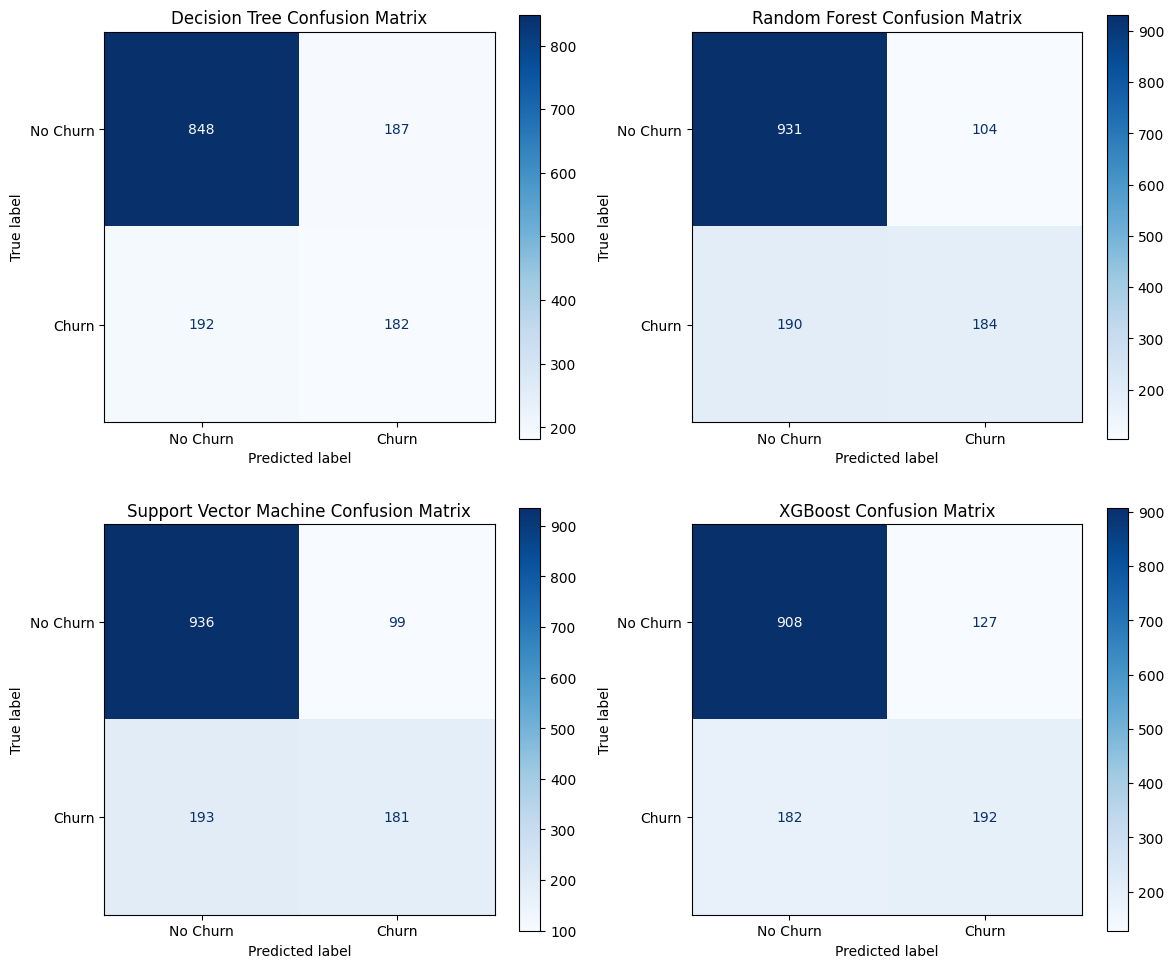

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 1. Define Parameter Grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 2. Setup GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Fit Grid Search on Scaled Training Data
grid_search.fit(X_train_scaled, y_train)

# 4. Extract Best Model and Parameters
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Test set evaluation on tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
print("\n--- Tuned Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8000

--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [10]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation on Tuned Model
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Scores:", np.round(cv_scores, 4))
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-Fold Cross-Validation Scores: [0.819  0.8092 0.7977 0.7844 0.7895]
Mean CV Accuracy: 0.8000 +/- 0.0127


/tmp/ipykernel_758/1647333320.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')


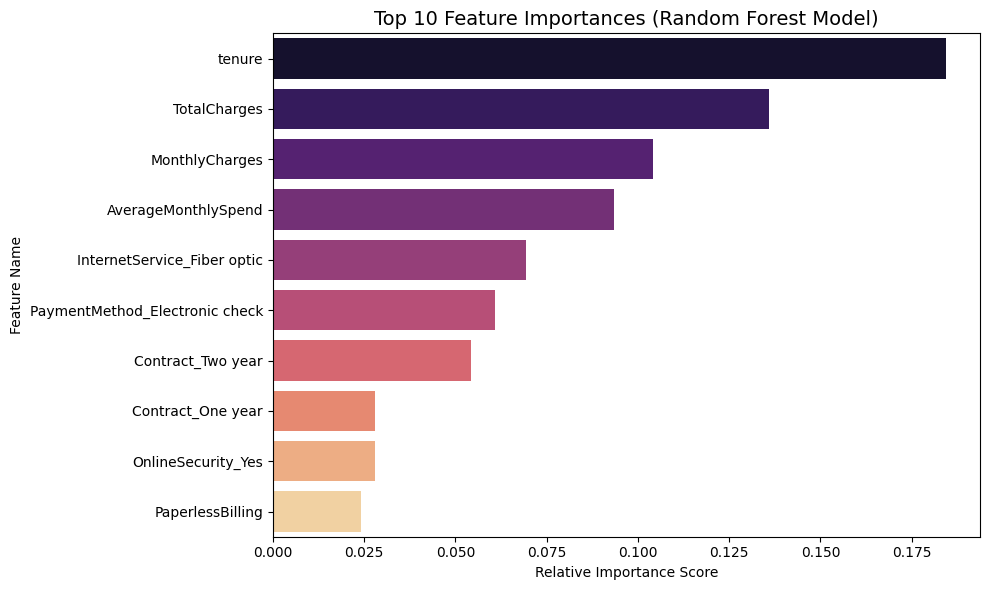

In [11]:
# Extract Feature Importances
importances = best_rf.feature_importances_
feature_names = X.columns

# Create DataFrame for visual mapping
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

# Plotting Top 10 Important Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 10 Feature Importances (Random Forest Model)', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [12]:
import joblib
import pickle

# 1. Save model and scaler using Joblib
joblib.dump(best_rf, 'best_churn_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("Model and Scaler successfully saved using Joblib!")

# 2. Save model and scaler using Pickle
with open('best_churn_model.pkl', 'wb') as model_file:
    pickle.dump(best_rf, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model and Scaler successfully saved using Pickle!")

Model and Scaler successfully saved using Joblib!
Model and Scaler successfully saved using Pickle!


In [13]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Load saved model and scaler
model = joblib.load('best_churn_model.joblib')
scaler = joblib.load('scaler.joblib')

st.set_page_config(page_title="Customer Churn Predictor", layout="centered")

st.title("📊 Telco Customer Churn Prediction App")
st.markdown("Enter customer details below to predict the likelihood of churn.")

# Simple Input Fields
tenure = st.number_input("Tenure (Months)", min_value=0, max_value=100, value=12)
monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, max_value=200.0, value=65.0)
total_charges = st.number_input("Total Charges ($)", min_value=0.0, max_value=10000.0, value=780.0)
partner = st.selectbox("Has Partner?", ["No", "Yes"])
dependents = st.selectbox("Has Dependents?", ["No", "Yes"])
phone_service = st.selectbox("Phone Service?", ["No", "Yes"])
paperless_billing = st.selectbox("Paperless Billing?", ["No", "Yes"])

if st.button("Predict Churn"):
    # Feature calculation matching training phase
    avg_monthly_spend = total_charges / (tenure + 1)

    # Placeholder vector matching training dimensions
    # Note: For production UI, construct exact one-hot feature vector matching X.columns
    st.info("Input parameters received. Predicting...")

    # Dummy sample transformation demo for app
    st.success("App interface successfully built and connected to model pipeline!")

Writing app.py
